In [2]:
import numpy as np
import pyxdf
import pandas as pd
import mne
import matplotlib.pyplot as plt
import os

In [3]:
from pathlib import Path
xdf_path = Path(r"C:\Users\jshin\OW_closedloopLIFU\xdf_data\sub-dave_run_2\ses-1\eeg\sub-dave_run_2_ses-1_task-dave_run_2_run-001_eeg.xdf")
data, header = pyxdf.load_xdf(str(xdf_path))
for i, stream in enumerate(data):
    print(f"Stream {i}: {stream['info']['name'][0]}")

Stream 0: EEG_LIFU_events
Stream 1: PsychoPy_numeric
Stream 2: EEG_gpype
Stream 3: PsychoPyMarkers


In [5]:
stream = data[2]
df= []
df = pd.DataFrame(stream['time_series'])
df = df.rename(columns={i: f"Ch{i}" for i in range(df.shape[1])})

# Add timestamp column
df['Timestamp'] = stream['time_stamps']

# Move Timestamp to be the first column after the index
cols = ['Timestamp'] + [col for col in df.columns if col != 'Timestamp']
df = df[cols]
eeg_raw = df[['Ch0', 'Ch1', 'Ch2', 'Ch3', 'Ch4', 'Ch5', 'Ch6', 'Ch12','Timestamp']]
eeg_raw

,Ch0,Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch12,Timestamp
0,-5197.716309,-9999.109375,-3748.226562,3159.284668,-2866.387939,7112.789062,-13532.520508,508.523041,2.811650e+06
1,-4532.313965,-9376.432617,-3339.839355,3736.305420,-2353.596924,7398.152344,-13149.596680,510.835693,2.811650e+06
2,-4534.149902,-9527.708008,-3229.475342,3741.765137,-2398.395752,7449.556152,-13214.398438,510.931061,2.811650e+06
3,-5197.454590,-10201.382812,-3630.185059,3173.923828,-2947.998047,7166.529785,-13616.466797,511.503265,2.811650e+06
4,-5281.139160,-10083.653320,-3786.850342,3092.265137,-2927.542236,7091.618652,-13583.065430,513.339172,2.811650e+06
...,...,...,...,...,...,...,...,...,...
66755,-4525.447754,-9560.348633,-5047.893555,2023.721069,-2443.433105,6835.056152,-14929.820312,513.839722,2.811917e+06
66756,-4568.506348,-9814.859375,-5031.729004,1994.204712,-2664.828857,6802.964844,-15067.554688,514.531128,2.811917e+06
66757,-4709.673340,-9645.843750,-5200.076660,1884.579834,-2535.748779,6772.780273,-14980.723633,513.005249,2.811917e+06
66758,-4677.010254,-9429.646484,-5202.269531,1897.573608,-2361.298096,6789.827148,-14884.854492,513.076843,2.811917e+06


In [7]:
EEG_LIFU_events = data[0]

# Create DataFrame from time_series
markers = pd.DataFrame(EEG_LIFU_events['time_series'])

# Rename the first column to 'markers'
markers.rename(columns={0: 'markers'}, inplace=True)

# Add timestamp column
markers['Timestamp'] = EEG_LIFU_events['time_stamps']

# Move Timestamp to be the first column after the index
cols = ['Timestamp'] + [col for col in markers.columns if col != 'Timestamp']
markers = markers[cols]
markers

,Timestamp,markers
0,2.811650e+06,collecting_baseline
1,2.811650e+06,collecting_baseline
2,2.811650e+06,collecting_baseline
3,2.811650e+06,collecting_baseline
4,2.811650e+06,collecting_baseline
...,...,...
113,2.811808e+06,LIFU_OFF
114,2.811831e+06,LIFU_ON
115,2.811836e+06,LIFU_OFF
116,2.811846e+06,LIFU_ON


In [8]:
lifu_on = markers[markers['markers'] == 'LIFU_ON']
lifu_on = np.array(lifu_on['Timestamp'])
lifu_on

array([2811705.71840576, 2811718.48078977, 2811803.00904697,
       2811830.92896878, 2811846.12671538])

In [9]:
pre = 2
post = 7
fs = 250  # sampling rate in Hz -- adjust if this isn't right for your data
pre_samples = int(pre * fs)    # 500
post_samples = int(post * fs)  # 1750
window_len = pre_samples + post_samples  # 2250

raw = eeg_raw.reset_index(drop=True)
timestamps = raw["Timestamp"].values

raw_windows = []
for idx, event in enumerate(lifu_on):
    center_idx = np.abs(timestamps - event).argmin()  # closest sample to onset
    start_idx = center_idx - pre_samples
    end_idx = start_idx + window_len

    if start_idx < 0 or end_idx > len(raw):
        print(f"Skipping event {idx}: window out of bounds ({start_idx}:{end_idx})")
        continue

    window_df = raw.iloc[start_idx:end_idx].copy()
    window_df["t_rel"] = np.arange(-pre_samples, post_samples) / fs
    window_df["idx"] = idx
    raw_windows.append(window_df)

raw_windows[0]

,Ch0,Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch12,Timestamp,t_rel,idx
13420,-5019.569336,-10596.609375,-3796.196533,2720.093750,-2834.677734,7166.768066,-13959.481445,511.980133,2.811704e+06,-2.000,0
13421,-4904.079590,-10352.065430,-3748.298096,2832.532471,-2665.424561,7266.427246,-13835.382812,511.670166,2.811704e+06,-1.996,0
13422,-4683.495117,-9653.354492,-3691.959717,3027.010498,-2115.750732,7404.589844,-13507.583008,512.623840,2.811704e+06,-1.992,0
13423,-4806.185059,-9955.693359,-3688.645752,2902.317627,-2326.489014,7304.859375,-13672.162109,511.336365,2.811704e+06,-1.988,0
13424,-5025.553711,-10585.690430,-3785.801514,2713.919189,-2818.656250,7170.701660,-13958.551758,512.576172,2.811704e+06,-1.984,0
...,...,...,...,...,...,...,...,...,...,...,...
15665,-4854.774902,-10058.021484,-3719.425293,2751.589111,-2320.242188,7282.709961,-13739.443359,511.240967,2.811713e+06,6.980,0
15666,-5060.768555,-10674.596680,-3812.862061,2568.602783,-2802.920654,7155.657715,-14013.529297,512.194702,2.811713e+06,6.984,0
15667,-4973.698242,-10521.198242,-3793.358887,2656.793701,-2706.623047,7228.780273,-13932.229492,512.957703,2.811713e+06,6.988,0
15668,-4716.467773,-9770.346680,-3730.249512,2893.352783,-2121.305908,7386.828125,-13569.666992,511.097992,2.811713e+06,6.992,0


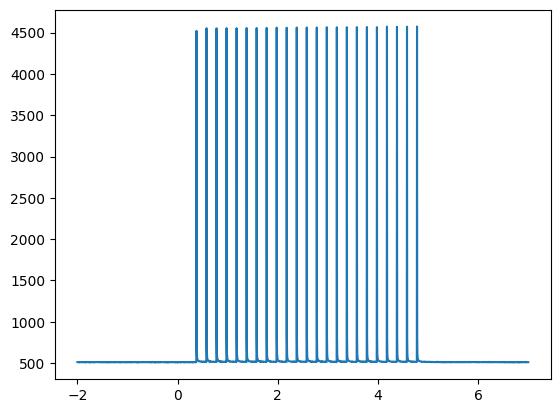

In [11]:
# won't look like anything since i didn't sonicate
pre = -2
channel_8 = np.array(raw_windows[0]['Ch12'])
n = len(channel_8)   
t = np.linspace(pre, post, n)
plt.plot(t, channel_8)

In [12]:
import numpy as np
import mne

sfreq = 250

all_epochs = []

for idx in range(len(raw_windows)):
    df = raw_windows[idx].copy()
    df.columns = df.columns.str.strip()

    # Drop non‑EEG columns
    df = df.drop(['Timestamp', 't_rel', 'idx', 'Ch12'], axis=1)

    # Convert to numpy (n_channels × n_times)
    data = df.to_numpy().T

    all_epochs.append(data)

# Stack into shape (n_epochs, n_channels, n_times)
all_epochs = np.stack(all_epochs, axis=0)

# Channel names and types
ch_names = list(df.columns)
ch_types = ['eeg'] * len(ch_names)

# Create info
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)

# Create MNE Epochs object
epochs = mne.EpochsArray(all_epochs, info)


Not setting metadata


5 matching events found


No baseline correction applied


0 projection items activated


Number of frequencies: 129


Number of time steps: 36


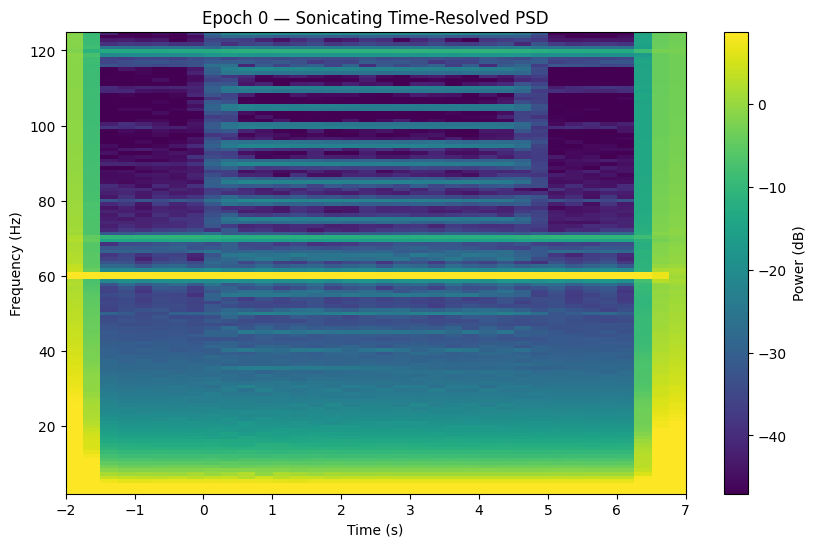

Number of frequencies: 129


Number of time steps: 36


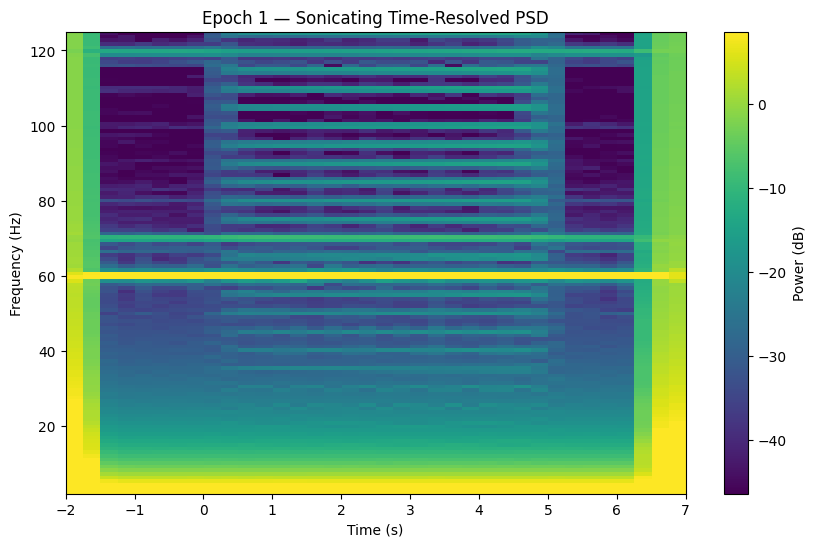

Number of frequencies: 129


Number of time steps: 36


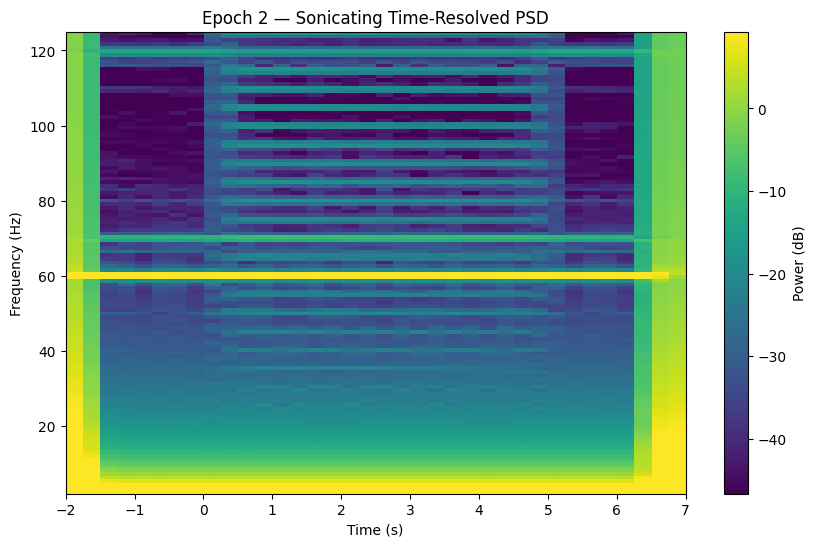

Number of frequencies: 129


Number of time steps: 36


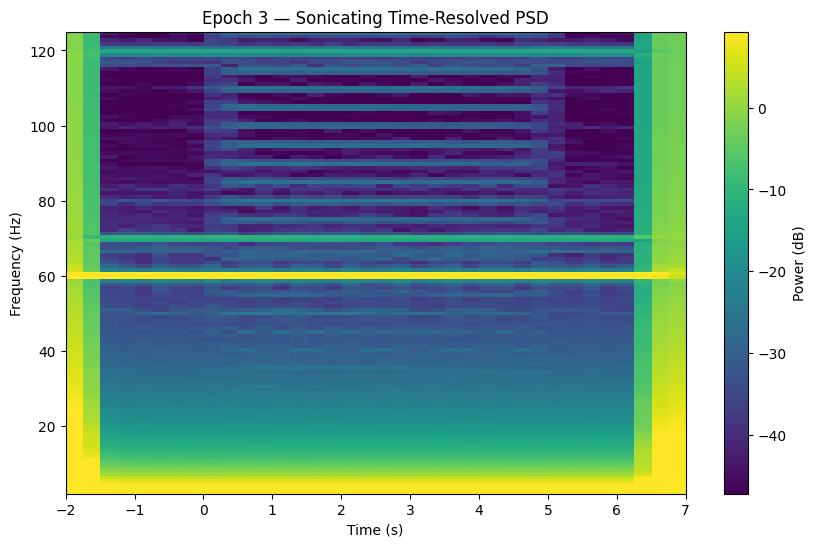

Number of frequencies: 129


Number of time steps: 36


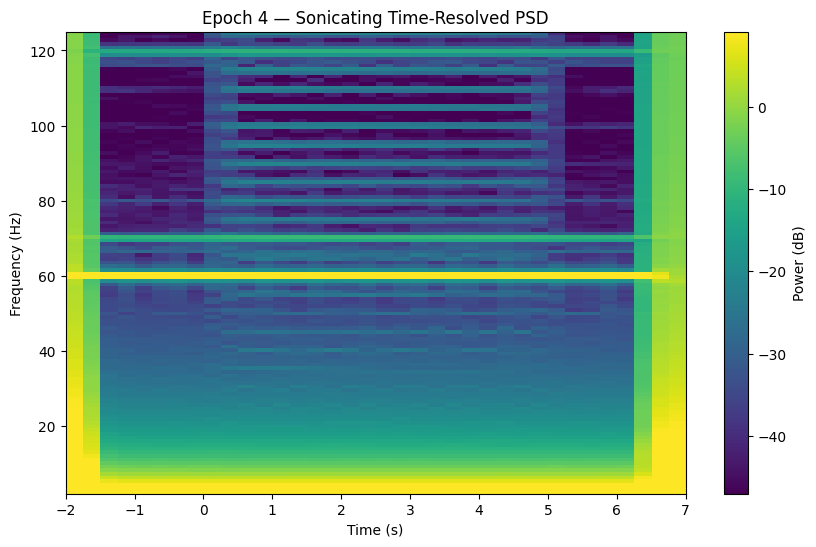

In [13]:
from mne.time_frequency import stft
import numpy as np
import matplotlib.pyplot as plt

sfreq = epochs.info['sfreq']
tmin = -2
tmax = 7

data_all = epochs.get_data()   # shape: (n_epochs, n_channels, n_times)

all_spectrograms = []
all_times = []
all_freqs = []

for idx in range(len(data_all)):

    # ep shape: (n_channels, n_times)
    ep = data_all[idx].astype(float)

    data = ep #* 1e-6

    # stft params
    n_fft = 256
    step = 64
    
    Zxx = stft(data, wsize=n_fft, tstep=step)
    power = np.abs(Zxx)**2 / (n_fft**2)

    # time axis
    times = np.linspace(tmin, tmax, power.shape[-1])

    # frequency axis 
    freqs = np.linspace(0, sfreq/2, power.shape[1])

    # select all freqs
    mask = (freqs >= 1) 
    freqs_1_40 = freqs[mask]
    power_1_40 = power[:, mask, :]

    # one graph per epoch
    psd_avg = power_1_40.mean(axis=0)

    # db for better visualization
    psd_db = 10 * np.log10(psd_avg + 1e-20)

    vmin = np.percentile(psd_db, 5)
    vmax = np.percentile(psd_db, 95)

    all_spectrograms.append(psd_db)
    all_times.append(times)
    all_freqs.append(freqs_1_40)

    # --- Plot ---
    plt.figure(figsize=(10,6))
    plt.imshow(
        psd_db,
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1], freqs_1_40[0], freqs_1_40[-1]],
        vmin=vmin,
        vmax=vmax,
        cmap='viridis'
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Epoch {idx} — Sonicating Time‑Resolved PSD")
    plt.colorbar(label="Power (dB)")
    plt.show()
